First experment, described in real\science\experiment_1_celebrities\exprement_description_link.txt

Requirments to run: HF_TOKEN setted

In [46]:
import sys
from pathlib import Path
import logging

# repo root = .../VisulaiztionInfoFlowDemo  (three parents up from this notebook)
REPO_ROOT = Path.cwd().parents[2] if (Path.cwd().name == "experiment_1_celebrities") else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))
CACHE_PATH = r"D:\expermient_celebrities"
ATOL = 3e-3

## 1. Data loading

### Load information to model

In [2]:
from pydantic import BaseModel


class RawSentenceData(BaseModel):
    sentence: str
    name_start_index: int
    name_end_index: int
    name: str

In [3]:
import json
import re

# Load a
with open(r"data\a_about_celebrities.json", "r", encoding="utf-8") as f:
    a_about_celebrities_dict = json.load(f)

a_about_celebrities: list[RawSentenceData] = []
for info in a_about_celebrities_dict:
    end_of_first_name_index = info["sentence"].find(" ", info["start_of_name_index"] + 1)
    end_of_last_name_index = (
        re.search(r" |'s", info["sentence"][end_of_first_name_index + 1 :]).start() + end_of_first_name_index + 1
    )
    a_about_celebrities.append(
        RawSentenceData(
            sentence=info["sentence"],
            name_start_index=info["start_of_name_index"],
            name_end_index=end_of_last_name_index,
            name=info["sentence"][info["start_of_name_index"] : end_of_last_name_index],
        )
    )


# Load b
with open(r"data\b_mentions_celebrities.json", "r", encoding="utf-8") as f:
    b_mentions_celebrities_dict = json.load(f)

b_mentions_celebrities: list[RawSentenceData] = []
for info in b_mentions_celebrities_dict:
    end_of_first_name_index = info["sentence"].find(" ", info["start_of_name_index"] + 1)
    end_of_last_name_index = (
        re.search(r" |'s", info["sentence"][end_of_first_name_index + 1 :]).start() + end_of_first_name_index + 1
    )
    b_mentions_celebrities.append(
        RawSentenceData(
            sentence=info["sentence"],
            name_start_index=info["start_of_name_index"],
            name_end_index=end_of_last_name_index,
            name=info["sentence"][info["start_of_name_index"] : end_of_last_name_index],
        )
    )

### Verify names indexes data

In [4]:
print("A data:")
for sentece_info in a_about_celebrities:
    print(f"Sentence: {sentece_info.sentence}| Name: {sentece_info.name}")

print("--------------------------------------------------------------")
print("B data")
for sentece_info in b_mentions_celebrities:
    print(f"Sentence: {sentece_info.sentence}| Name: {sentece_info.name}")

A data:
Sentence: Taylor Swift kicked off her world tour with a three-hour setlist spanning every era of her career.| Name: Taylor Swift
Sentence: Did you see that Dwayne Johnson posted a new workout video this morning?| Name: Dwayne Johnson
Sentence: In a statement released Thursday, Emma Watson announced her return to acting after a brief hiatus.| Name: Emma Watson
Sentence: Honestly, I think Ryan Reynolds is one of the funniest people in Hollywood right now.| Name: Ryan Reynolds
Sentence: Serena Williams retired from professional tennis after an illustrious career spanning over two decades.| Name: Serena Williams
Sentence: Breaking: Elon Musk's latest venture has sparked intense debate among industry analysts.| Name: Elon Musk
Sentence: My mom absolutely adores Tom Hanks — she's seen every single one of his movies.| Name: Tom Hanks
Sentence: Beyoncé Knowles surprised fans with an unannounced album drop late last night.| Name: Beyoncé Knowles
Sentence: According to sources close to t

### Load generated fake celebrities names

In [5]:
import random

with open(r"data\fake_celebrities_63_tokens.json", "r", encoding="utf-8") as f:
    alternative_names = json.load(f)
random.seed(1321)
random.shuffle(alternative_names)

### Show sums of token number are equal (model dependent)

#### Setup

In [6]:
from dotenv import load_dotenv
import os

load_dotenv(r"..\..\..\.env.local")
HF_TOKEN = os.getenv("HF_TOKEN")

In [7]:
MODEL = "meta-llama/Llama-3.1-8B"

In [8]:
from pathlib import Path
from api_checks.api_cache import ModelAPICache
from tqdm import tqdm

model_api_cache = ModelAPICache(cache_path=Path(CACHE_PATH), hf_token=HF_TOKEN)
model_calcutor = model_api_cache.get_infomration_calculator(MODEL)

#### Calculate sum tokens amount

In [9]:
def calc_sum_name_tokens_amount(raw_sentences_data: list[RawSentenceData]) -> int:
    names_total_tokens = 0
    for sentence_info in raw_sentences_data:
        tokens_num = len(model_calcutor.calc_tokens(sentence_info.name)) - 1  # Dont include BOS
        names_total_tokens += tokens_num
    return names_total_tokens


total_names_tokens_a = calc_sum_name_tokens_amount(a_about_celebrities)
total_names_tokens_b = calc_sum_name_tokens_amount(b_mentions_celebrities)

total_fake_names_tokens = 0
for name in alternative_names:
    tokens_num = len(model_calcutor.calc_tokens(name)) - 1  # Dont include BOS
    total_fake_names_tokens += tokens_num

In [10]:
assert total_names_tokens_a == total_names_tokens_b == total_fake_names_tokens
print(f"All total tokens number in names are equal to {total_names_tokens_a}")

All total tokens number in names are equal to 63


### Replace information in sentences

In [11]:
a_sentnces_fake_names = [
    raw_sentence_info.sentence.replace(raw_sentence_info.name, fake_name)
    for raw_sentence_info, fake_name in zip(a_about_celebrities, alternative_names)
]
b_sentences_fake_names = [
    raw_sentence_info.sentence.replace(raw_sentence_info.name, fake_name)
    for raw_sentence_info, fake_name in zip(b_mentions_celebrities, alternative_names)
]

In [12]:
for i, sentence in enumerate(a_sentnces_fake_names):
    print(i, sentence)

0 Lennox Riv kicked off her world tour with a three-hour setlist spanning every era of her career.
1 Did you see that Selah Winters posted a new workout video this morning?
2 In a statement released Thursday, Dash Vega announced her return to acting after a brief hiatus.
3 Honestly, I think Jasper Mon is one of the funniest people in Hollywood right now.
4 Harlow Vance retired from professional tennis after an illustrious career spanning over two decades.
5 Breaking: Zephyr Holt's latest venture has sparked intense debate among industry analysts.
6 My mom absolutely adores Sable Cross — she's seen every single one of his movies.
7 Nova Stern surprised fans with an unannounced album drop late last night.
8 According to sources close to the actor, Marlowe Sin has been spending more time out of the public eye.
9 You know, Wren Ash used to trip on the red carpet a lot before she became a huge star.
10 Kai Ambrose led his team to victory in a thrilling overtime match.
11 The documentary abo

In [13]:
for i, sentence in enumerate(b_sentences_fake_names):
    print(i, sentence)

0 I was running late so I just threw on whatever was clean and grabbed my coffee, not that Lennox Riv ever has that problem.
1 The bakery on Fifth Street sells out of croissants by 9am most days, especially since it's two blocks from where Selah Winters supposedly grabbed breakfast once.
2 Local officials announced Tuesday that the new community center will open in September, with Dash Vega rumored to attend the ribbon-cutting ceremony.
3 lol my wifi has been down for three hours, meanwhile Jasper Mon probably has like six satellites just for his backyard.
4 The recipe calls for two cups of flour and a pinch of salt — my aunt swears it's the same one Harlow Vance uses.
5 Traffic on the interstate was backed up this afternoon after a jackknifed truck spilled its cargo, delaying even Zephyr Holt's tour bus, according to one bystander's tweet.
6 honestly i just want a nap and a sandwich, is that too much to ask, Sable Cross probably naps whenever she wants.
7 The museum's new exhibit feat

In [14]:
def fake_name_sentences_to_sentence_raw_data(
    sentences_with_fake_names: list[str], sentences_raw_data: list[RawSentenceData], fake_names: list[str]
) -> list[RawSentenceData]:
    result = []
    for fake_sentence, sentence_raw_data, fake_name in zip(sentences_with_fake_names, sentences_raw_data, fake_names):
        fake_sentence_raw_data = RawSentenceData(
            sentence=fake_sentence,
            name_start_index=sentence_raw_data.name_start_index,
            name_end_index=sentence_raw_data.name_start_index + len(fake_name),
            name=fake_name,
        )
        result.append(fake_sentence_raw_data)
    return result


a_fake_names_raw_data = fake_name_sentences_to_sentence_raw_data(
    a_sentnces_fake_names, a_about_celebrities, alternative_names
)
b_fake_names_raw_data = fake_name_sentences_to_sentence_raw_data(
    b_sentences_fake_names, b_mentions_celebrities, alternative_names
)

### Orgnize sentence by tokens (model dependent)

In [ ]:
class SentenceTokensInformation(BaseModel):
    sentence: str
    tokens: list[str]
    name_tokens_indexes: list[int]


def sentence_token_information_from_raw_data(raw_sentence_data: RawSentenceData, model_name: str):
    calculator = model_api_cache.get_infomration_calculator(model_name)
    sentence_tokens = calculator.calc_tokens(raw_sentence_data.sentence)

    current_character_index = 0
    current_token_index = 1  # skip BOS
    name_tokens_indexes = []
    while current_character_index < raw_sentence_data.name_start_index:
        current_character_index += len(sentence_tokens[current_token_index])
        current_token_index += 1
    if current_token_index > 1:  # Dont add BOS
        name_tokens_indexes.append(current_token_index - 1)
    while current_character_index < raw_sentence_data.name_end_index:
        name_tokens_indexes.append(current_token_index)
        current_character_index += len(sentence_tokens[current_token_index])
        current_token_index += 1

    # In case token include token name
    return SentenceTokensInformation(
        sentence=raw_sentence_data.sentence, tokens=sentence_tokens, name_tokens_indexes=name_tokens_indexes
    )

In [16]:
a_tokens_info = [
    sentence_token_information_from_raw_data(sentence_raw_data, MODEL) for sentence_raw_data in a_about_celebrities
]
a_fake_name_tokens_info = [
    sentence_token_information_from_raw_data(sentence_raw_data, MODEL) for sentence_raw_data in a_fake_names_raw_data
]
b_tokens_info = [
    sentence_token_information_from_raw_data(sentence_raw_data, MODEL) for sentence_raw_data in b_mentions_celebrities
]
b_fake_name_tokens_info = [
    sentence_token_information_from_raw_data(sentence_raw_data, MODEL) for sentence_raw_data in b_fake_names_raw_data
]

In [17]:
a_tokens_info = (a_tokens_info, a_fake_name_tokens_info)
b_tokens_info = (b_tokens_info, b_fake_name_tokens_info)
print(a_tokens_info)

([SentenceTokensInformation(sentence='Taylor Swift kicked off her world tour with a three-hour setlist spanning every era of her career.', tokens=['<|begin_of_text|>', 'Taylor', ' Swift', ' kicked', ' off', ' her', ' world', ' tour', ' with', ' a', ' three', '-hour', ' set', 'list', ' spanning', ' every', ' era', ' of', ' her', ' career', '.'], name_tokens_indexes=[1, 2]), SentenceTokensInformation(sentence='Did you see that Dwayne Johnson posted a new workout video this morning?', tokens=['<|begin_of_text|>', 'Did', ' you', ' see', ' that', ' D', 'wayne', ' Johnson', ' posted', ' a', ' new', ' workout', ' video', ' this', ' morning', '?'], name_tokens_indexes=[5, 6, 7]), SentenceTokensInformation(sentence='In a statement released Thursday, Emma Watson announced her return to acting after a brief hiatus.', tokens=['<|begin_of_text|>', 'In', ' a', ' statement', ' released', ' Thursday', ',', ' Emma', ' Watson', ' announced', ' her', ' return', ' to', ' acting', ' after', ' a', ' brief',

### Check that same amount of tokens after name

In [18]:
def check_same(group_tokens_info: tuple[list[SentenceTokensInformation], list[SentenceTokensInformation]]):
    for real_sent, fake_sent in zip(group_tokens_info[0], group_tokens_info[1]):
        assert len(real_sent.tokens) - max(real_sent.name_tokens_indexes) == len(fake_sent.tokens) - max(
            fake_sent.name_tokens_indexes
        ), f"Error, not same amount of tokens after name\n Real: {real_sent.tokens} | Fake: {fake_sent.tokens}"


check_same(a_tokens_info)
check_same(b_tokens_info)

## 2. load data

### Answering which matric to use, ratio or proprotions
A fundmental question to ask is which metric to use to calculate incresment in celbrity token, there are two native options:

(a) contribution_celeb/full_position : contribution_fake/full_position -> relative proprtions of position  
(b) contribution_celeb/contribution_fake : other_part_of_positon_celeb/other_part_of_position_fake -> relative ratio of proportions/ by how much token increaed with respect to other part

This comes down to the fundmental question of whether the model remix position token in other way (a), or adds a new contribution vector to the existing one (b), The decision three that intutivly dittinguish those is:
1. If position norms are relativly the same at all positions its mix -> plot norm ratios see how much they all close to 1, up to 10% is good
2. Not 1 and norms of other part are relativly the same its (b)
3. Not 1,2 If normsother parts relative to current part are high in variance, and do not increase by a relaitvly constant amount, its (b) (data is added to evrything, not constant)
4. Not 1,2,3 If norms of other part are high in varince and somtimes even decreasing, its a mix

Caveat: It has been imperaclly observed that its almost always the case that BOS has a very large norm, it could be the case that it noise the response, and its actually b, but the size of the BOS make it looks like c. I should repeat each exprement without BOC


In [19]:
import os

# Get the current working directory (home directory from which the script is run)
home_dir = os.getcwd()
print("Current working directory (home dir):", home_dir)

Current working directory (home dir): c:\Users\wildn\Desktop\New life\AI\Expirments\VisulaiztionInfoFlowDemo\real\science\experiment_1_celebrities


#### First exprment setup

In [20]:

from pydantic_settings import SettingsConfigDict

from api_checks.full_run_result import Contributions, FullRunResults
import torch

from api_checks.utils import TokenpacksIndexed, get_tokenpacks_indexed_contributions

class ResidualNorms(BaseModel):
    post_mlp_norms: torch.Tensor  # (layers,positon)
    post_attention_norms: torch.Tensor  # (layers,position)

    model_config = SettingsConfigDict(arbitrary_types_allowed=True)


class FullPositionsNormsExperimentInfo(BaseModel):
    sentence_real_tokens_info: SentenceTokensInformation
    sentence_fake_tokens_info: SentenceTokensInformation
    full_positions_relevant_norms: tuple[ResidualNorms, ResidualNorms]  # real,fake
    full_sentence_no_bos_relevant_norms: tuple[ResidualNorms, ResidualNorms]


L2_NORM = lambda x: x.norm(dim=-1)


def calc_residual_norms(
    sentence_tokens_info: SentenceTokensInformation, model_name: str, norm_func: callable = L2_NORM
) -> ResidualNorms:
    full_run_result = model_api_cache.get_full_run_results(prompt=sentence_tokens_info.sentence, model_name=model_name)
    grouped_result = get_tokenpacks_indexed_contributions(
        mask=[0] * len(sentence_tokens_info.tokens), contributions=full_run_result.contributions
    )  # (layer,residual_position,1)
    post_mlp_norms = norm_func(grouped_result.tokenpacks_contributions.post_mlp_contribution).squeeze(dim=[-1])
    post_attention_norms = norm_func(grouped_result.tokenpacks_contributions.post_attention_contribution).squeeze(
        dim=[-1]
    )
    assert len(post_mlp_norms.shape) == len(post_attention_norms.shape) == 2
    return ResidualNorms(post_mlp_norms=post_mlp_norms, post_attention_norms=post_attention_norms)


def calc_residual_norms_no_BOS(
    sentence_tokens_info: SentenceTokensInformation, model_name: str, norm_func: callable = L2_NORM
) -> ResidualNorms:
    full_run_result = model_api_cache.get_full_run_results(prompt=sentence_tokens_info.sentence, model_name=model_name)
    grouped_result = get_tokenpacks_indexed_contributions(
        mask=[0] + [1] * (len(sentence_tokens_info.tokens) - 1), contributions=full_run_result.contributions
    )  # (layer,residual,position,1)
    post_mlp_norms = norm_func(grouped_result.tokenpacks_contributions.post_mlp_contribution)[..., 1]
    post_attention_norms = norm_func(grouped_result.tokenpacks_contributions.post_attention_contribution)[..., 1]
    assert len(post_mlp_norms.shape) == len(post_attention_norms.shape) == 2
    return ResidualNorms(post_mlp_norms=post_mlp_norms, post_attention_norms=post_attention_norms)


def trim_residual_norms(residual_norms: ResidualNorms, indexes: list | range) -> ResidualNorms:
    return ResidualNorms(
        post_attention_norms=residual_norms.post_attention_norms.index_select(dim=1, index=torch.tensor(list(indexes))),
        post_mlp_norms=residual_norms.post_mlp_norms.index_select(dim=1, index=torch.tensor(list(indexes))),
    )





In [21]:
def calc_trimmed_full_position_norm_info(
    sentence_tokens_info_real: SentenceTokensInformation,
    sentence_tokens_info_fake: SentenceTokensInformation,
    model_name: str,
    norm_func: callable = L2_NORM,
):
    resdiual_norms = [
        calc_residual_norms(sentence_tokens_info_real, model_name, norm_func),
        calc_residual_norms(sentence_tokens_info_fake, model_name, norm_func),
    ]
    resdiual_norms[0] = trim_residual_norms(resdiual_norms[0], range(max(sentence_tokens_info_real.name_tokens_indexes)+1,len(sentence_tokens_info_real.tokens)))
    resdiual_norms[1] = trim_residual_norms(resdiual_norms[1], range(max(sentence_tokens_info_fake.name_tokens_indexes)+1,len(sentence_tokens_info_fake.tokens)))

    resdiual_no_bos_norms = [
        calc_residual_norms_no_BOS(sentence_tokens_info_real, model_name, norm_func),
        calc_residual_norms_no_BOS(sentence_tokens_info_fake, model_name, norm_func),
    ]
    resdiual_no_bos_norms[0] = trim_residual_norms(resdiual_no_bos_norms[0], range(max(sentence_tokens_info_real.name_tokens_indexes)+1,len(sentence_tokens_info_real.tokens)))
    resdiual_no_bos_norms[1] = trim_residual_norms(resdiual_no_bos_norms[1], range(max(sentence_tokens_info_fake.name_tokens_indexes)+1,len(sentence_tokens_info_fake.tokens)))
    return FullPositionsNormsExperimentInfo(
        sentence_real_tokens_info=sentence_tokens_info_real,
        sentence_fake_tokens_info=sentence_tokens_info_fake,
        full_positions_relevant_norms=tuple(resdiual_norms),
        full_sentence_no_bos_relevant_norms=tuple(resdiual_no_bos_norms),
    )

In [22]:
about_celebrities_expriment_info:FullPositionsNormsExperimentInfo = []
for (real_sentence,fake_sentence) in tqdm((list(zip(*a_tokens_info))+list(zip(*a_tokens_info)))):
    about_celebrities_expriment_info.append(calc_trimmed_full_position_norm_info(real_sentence,fake_sentence,model_name=MODEL))

  0%|          | 0/40 [00:00<?, ?it/s]

CACHE HIT meta-llama/Llama-3.1-8B Taylor Swift kicked off her world tour with a three-hour setlist spanning every era of her career. 2026-07-08 16:40:53.760000


  0%|          | 0/40 [00:11<?, ?it/s]


KeyboardInterrupt: 

#### First expriment data gathering

#### sainity checks

In [ ]:
position_norm_expirment_info:list[FullPositionsNormsExperimentInfo] = about_celebrities_expriment_info
for expirment_info in position_norm_expirment_info:
    assert expirment_info.sentence_real_tokens_info.tokens[max(expirment_info.sentence_real_tokens_info.name_tokens_indexes)+1:] == expirment_info.sentence_fake_tokens_info.tokens[max(expirment_info.sentence_fake_tokens_info.name_tokens_indexes)+1:]
    print(f"{expirment_info.sentence_real_tokens_info.tokens[min(expirment_info.sentence_real_tokens_info.name_tokens_indexes):max(expirment_info.sentence_real_tokens_info.name_tokens_indexes)+1]}| {expirment_info.sentence_fake_tokens_info.tokens[min(expirment_info.sentence_fake_tokens_info.name_tokens_indexes):max(expirment_info.sentence_fake_tokens_info.name_tokens_indexes)+1]}")
    num_of_post_names_tokens = len(expirment_info.sentence_real_tokens_info.tokens[max(expirment_info.sentence_real_tokens_info.name_tokens_indexes)+1:])
    print(num_of_post_names_tokens)
    assert num_of_post_names_tokens == expirment_info.full_positions_relevant_norms[0].post_attention_norms.shape[1] == expirment_info.full_positions_relevant_norms[0].post_mlp_norms.shape[1]
    assert num_of_post_names_tokens == expirment_info.full_positions_relevant_norms[1].post_attention_norms.shape[1] == expirment_info.full_positions_relevant_norms[1].post_mlp_norms.shape[1]
    assert num_of_post_names_tokens == expirment_info.full_sentence_no_bos_relevant_norms[0].post_attention_norms.shape[1] == expirment_info.full_sentence_no_bos_relevant_norms[0].post_mlp_norms.shape[1]
    assert num_of_post_names_tokens == expirment_info.full_sentence_no_bos_relevant_norms[1].post_attention_norms.shape[1] == expirment_info.full_sentence_no_bos_relevant_norms[1].post_mlp_norms.shape[1]

#### Plot full norms change

In [ ]:
full_position_ratio_attention = torch.cat([(exp_info.full_positions_relevant_norms[0].post_attention_norms/exp_info.full_positions_relevant_norms[1].post_attention_norms).flatten() for exp_info in position_norm_expirment_info])
full_position_ratio_mlp = torch.cat([(exp_info.full_positions_relevant_norms[0].post_mlp_norms/exp_info.full_positions_relevant_norms[1].post_mlp_norms).flatten() for exp_info in position_norm_expirment_info])
full_position_ratios = torch.cat([full_position_ratio_attention,full_position_ratio_mlp])



In [109]:
#VIBECODED
import matplotlib.pyplot as plt
import numpy as np



def plot_ratio_hist(flat: torch.Tensor, bins: int = 80):
    x = flat.detach().float().cpu().numpy()
    x = x[np.isfinite(x)]
    mean = x.mean()
    geo_mean = np.exp(np.log(x).mean())  # geometric mean, natural for ratios
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(x, bins=bins, color="#4c72b0", edgecolor="white", linewidth=0.3)
    ax.axvline(1.0, color="#c44e52", linewidth=1.2)
    ax.axvline(mean, color="#333333", linewidth=1.0, linestyle="--")
    ax.axvline(geo_mean, color="#55a868", linewidth=1.0, linestyle="--")
    # values on the x-axis, stacked at different heights so they never overlap
    ax.text(mean, -0.06, f"{mean:.3f}", ha="center", va="top",
            color="#333333", fontweight="bold", transform=ax.get_xaxis_transform())
    ax.text(geo_mean, -0.13, f"{geo_mean:.3f}", ha="center", va="top",
            color="#55a868", fontweight="bold", transform=ax.get_xaxis_transform())
    # legend so the two dashed lines are distinguishable
    ax.plot([], [], color="#333333", linestyle="--", label="mean")
    ax.plot([], [], color="#55a868", linestyle="--", label="geom. mean")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_xlabel("ratio")
    ax.set_ylabel("count")
    ax.legend(frameon=False)
    plt.tight_layout()
    plt.show()

plot_ratio_hist(full_position_ratios)


NameError: name 'full_position_ratios' is not defined

Seems like not that much change,lets see how no bos is

In [ ]:
full_position_no_bos_ratio_attention = torch.cat([(exp_info.full_sentence_no_bos_relevant_norms[0].post_attention_norms/exp_info.full_sentence_no_bos_relevant_norms[1].post_attention_norms).flatten() for exp_info in position_norm_expirment_info])
full_position_no_bos_ratio_mlp = torch.cat([(exp_info.full_sentence_no_bos_relevant_norms[0].post_mlp_norms/exp_info.full_sentence_no_bos_relevant_norms[1].post_mlp_norms).flatten() for exp_info in position_norm_expirment_info])
full_position_no_bos_ratios = torch.cat([full_position_no_bos_ratio_attention,full_position_no_bos_ratio_mlp])



In [ ]:
plot_ratio_hist(full_position_no_bos_ratios)

No BOS mean norms ratio is still very close to 1, not enoguh change to be sagnificant

plot_ratio_hist(full_position_ratios)


### Conclusion 
The remixing (a) perspective is the most accurate, and the one that it will be used   
contribution_celeb/full_position : contribution_fake/full_position -> relative proprtions of position 

If exprmient show negative result on some cases (norm dosent increase) (for example, on all last layers, norm dosent increase) revise, and plot again only on other cases

In [23]:
def relative_norm_increasment(
    celeb_contribution_norm: float,
    celeb_position_contribution_norm: float,
    fake_celeb_contribution_norm: float,
    fake_celeb_position_norm: float,
) -> float:
    return (celeb_contribution_norm / celeb_position_contribution_norm) / (fake_celeb_contribution_norm / fake_celeb_position_norm)

## Expirment 2

### Eache expremtn (a and b) will be saved as ExpermentPair containing the
- Tokenpakcs information (same as tokens informatio but with name as one token)
- The cottributions norms of the tokenpacks

In [84]:


class ContributionsNorms(BaseModel):
    post_attention_contributions_norms: torch.Tensor  # (layer,position (prompt_len_after_name),source (prompt_len))
    post_mlp_contributions_norms: torch.Tensor  # (layer,position (prompt_len_after_name),source (prompt_len))

    model_config = SettingsConfigDict(arbitrary_types_allowed=True)


class SentenceTokenPacksInformation(BaseModel):
    sentence: str
    tokenpacks: list[str]
    name_token_index: int
    original_tokens_info: SentenceTokensInformation


class ExprimentPair(BaseModel):
    real_names: tuple[SentenceTokenPacksInformation, ContributionsNorms]
    fake_names: tuple[SentenceTokenPacksInformation, ContributionsNorms]

#### Util functions for converting data formats

In [85]:
def _contributions_to_contributions_norm(
    contributions: Contributions, norm_func: callable = lambda x: x.norm(dim=-1)
) -> ContributionsNorms:
    post_attention_contributions_norms = norm_func(contributions.post_attention_contribution)
    post_mlp_contributions_norms = norm_func(contributions.post_mlp_contribution)
    return ContributionsNorms(
        post_attention_contributions_norms=post_attention_contributions_norms,
        post_mlp_contributions_norms=post_mlp_contributions_norms,
    )


def _mask_by_celeb_name(
    sentence_tokens_info: SentenceTokensInformation, contributions: Contributions
) -> tuple[SentenceTokenPacksInformation, TokenpacksIndexed]:
    mask = [0]
    token_packs = [sentence_tokens_info.tokens[0]]
    sentence_tokens = sentence_tokens_info.tokens
    name_index = None
    for i in range(1, len(sentence_tokens)):
        if i not in sentence_tokens_info.name_tokens_indexes[1:]:
            mask.append(mask[i - 1] + 1)
            token_packs.append(sentence_tokens[i])
        else:
            name_index = mask[i - 1]
            mask.append(mask[i - 1])
            token_packs[mask[i - 1]] += sentence_tokens[i]
    tokenpacks_indexed_contributions = get_tokenpacks_indexed_contributions(
        mask, contributions, tokens=sentence_tokens_info.tokens
    )
    assert tokenpacks_indexed_contributions.tokenpacks == token_packs  # same thing, calculated to get the name index
    sentence_tokenpacks_information = SentenceTokenPacksInformation(
        sentence=sentece_info.sentence, tokenpacks=token_packs, name_token_index=name_index,original_tokens_info=sentence_tokens_info
    )
    return (sentence_tokenpacks_information, tokenpacks_indexed_contributions)

### Calculate the experment info

1. Trace contributions
2. tokenpack name
3. calc norm

In [86]:
def trace_full_norms(
    sentence_tokens_info: SentenceTokensInformation, model: str
) -> tuple[SentenceTokenPacksInformation, ContributionsNorms]:
    sent_full_run_result = model_api_cache.get_full_run_results(model_name=model, prompt=sentence_tokens_info.sentence)
    sentence_token_packs_info, contributions_grouped_by_celeb = _mask_by_celeb_name(
        sentence_tokens_info, sent_full_run_result.contributions
    )
    sent_contributions_norms = _contributions_to_contributions_norm(
        contributions_grouped_by_celeb.tokenpacks_contributions
    )
    return sentence_token_packs_info, sent_contributions_norms


def calculate_expirment_info(
    group_tokens_info: tuple[list[SentenceTokensInformation], list[SentenceTokensInformation]], model: str
) -> list[ExprimentPair]:
    experiment_group = []
    for real_sent, fake_sent in tqdm(zip(group_tokens_info[0], group_tokens_info[1])):
        expriment_pair = ExprimentPair(
            real_names=trace_full_norms(real_sent, model=model),
            fake_names=trace_full_norms(fake_sent, model=model),
        )
        experiment_group.append(expriment_pair)
    return experiment_group

In [87]:
import nnsight

nnsight.CONFIG.APP.REMOTE_LOGGING = False

In [88]:
a_experiment_info = calculate_expirment_info(a_tokens_info,model=MODEL)
b_expiriment_info = calculate_expirment_info(b_tokens_info,model=MODEL)

0it [00:00, ?it/s]

CACHE HIT meta-llama/Llama-3.1-8B Taylor Swift kicked off her world tour with a three-hour setlist spanning every era of her career. 2026-07-08 16:40:53.760000
CACHE HIT meta-llama/Llama-3.1-8B Lennox Riv kicked off her world tour with a three-hour setlist spanning every era of her career. 2026-07-08 16:42:32.510000


1it [00:12, 12.24s/it]

CACHE HIT meta-llama/Llama-3.1-8B Did you see that Dwayne Johnson posted a new workout video this morning? 2026-07-08 16:42:30.380000


2it [00:16,  7.81s/it]

...

18it [04:08, 11.40s/it]

CACHE HIT meta-llama/Llama-3.1-8B The farmers market moved to a new location this year, right next to the mural someone painted of Beyoncé Knowles last spring. 2026-07-09 00:54:08.300000
CACHE HIT meta-llama/Llama-3.1-8B The farmers market moved to a new location this year, right next to the mural someone painted of Orion Fay last spring. 2026-07-09 10:57:54.940000


19it [04:20, 11.44s/it]

CACHE HIT meta-llama/Llama-3.1-8B It's wild how a random Spotify playlist algorithm knows my mood better than most of my actual friends do, no Adele Adkins needed to explain that one. 2026-07-09 00:56:02.270000
CACHE HIT meta-llama/Llama-3.1-8B It's wild how a random Spotify playlist algorithm knows my mood better than most of my actual friends do, no Mari Cruz needed to explain that one. 2026-07-09 11:00:47.680000


20it [04:38, 13.91s/it]


#### Validate name in index
Should produce only names and lists of token with names groupd

In [89]:
for ei in a_experiment_info:
    print(ei.real_names[0].tokenpacks)
    print(ei.fake_names[0].tokenpacks)
    print(ei.real_names[0].tokenpacks[ei.real_names[0].name_token_index])
    print(ei.fake_names[0].tokenpacks[ei.fake_names[0].name_token_index])
    assert ei.real_names[0].name_token_index == ei.fake_names[0].name_token_index
print("Expirment B")
for ei in b_expiriment_info:
    print(ei.fake_names[0].tokenpacks)
    print(ei.fake_names[0].tokenpacks)
    print(ei.real_names[0].tokenpacks[ei.real_names[0].name_token_index])
    print(ei.fake_names[0].tokenpacks[ei.fake_names[0].name_token_index])
    assert ei.real_names[0].name_token_index == ei.fake_names[0].name_token_index

['<|begin_of_text|>', 'Taylor Swift', ' kicked', ' off', ' her', ' world', ' tour', ' with', ' a', ' three', '-hour', ' set', 'list', ' spanning', ' every', ' era', ' of', ' her', ' career', '.']
['<|begin_of_text|>', 'Lennox Riv', ' kicked', ' off', ' her', ' world', ' tour', ' with', ' a', ' three', '-hour', ' set', 'list', ' spanning', ' every', ' era', ' of', ' her', ' career', '.']
Taylor Swift
Lennox Riv
['<|begin_of_text|>', 'Did', ' you', ' see', ' that', ' Dwayne Johnson', ' posted', ' a', ' new', ' workout', ' video', ' this', ' morning', '?']
['<|begin_of_text|>', 'Did', ' you', ' see', ' that', ' Selah Winters', ' posted', ' a', ' new', ' workout', ' video', ' this', ' morning', '?']
 Dwayne Johnson
 Selah Winters
['<|begin_of_text|>', 'In', ' a', ' statement', ' released', ' Thursday', ',', ' Emma Watson', ' announced', ' her', ' return', ' to', ' acting', ' after', ' a', ' brief', ' hiatus', '.']
['<|begin_of_text|>', 'In', ' a', ' statement', ' released', ' Thursday', ',

Calc full residual norms per group

In [90]:
def calc_full_position_norm_info(
    sentence_tokens_info_real: SentenceTokensInformation,
    sentence_tokens_info_fake: SentenceTokensInformation,
    model_name: str,
    norm_func: callable = L2_NORM,
):
    resdiual_norms = (
        calc_residual_norms(sentence_tokens_info_real, model_name, norm_func),
        calc_residual_norms(sentence_tokens_info_fake, model_name, norm_func)
    )
    resdiual_no_bos_norms = (
        calc_residual_norms_no_BOS(sentence_tokens_info_real, model_name, norm_func),
        calc_residual_norms_no_BOS(sentence_tokens_info_fake, model_name, norm_func),
    )
    return FullPositionsNormsExperimentInfo(
        sentence_real_tokens_info=sentence_tokens_info_real,
        sentence_fake_tokens_info=sentence_tokens_info_fake,
        full_positions_relevant_norms=tuple(resdiual_norms),
        full_sentence_no_bos_relevant_norms=tuple(resdiual_no_bos_norms),
    )

In [91]:
a_full_norms_ei: list[FullPositionsNormsExperimentInfo] = []
for real_sentence, fake_sentence in tqdm(list(zip(*a_tokens_info))):
    a_full_norms_ei.append(calc_full_position_norm_info(real_sentence, fake_sentence, model_name=MODEL))
b_full_norms_ei: list[FullPositionsNormsExperimentInfo] = []
for real_sentence, fake_sentence in tqdm(list(zip(*b_tokens_info))):
    b_full_norms_ei.append(calc_full_position_norm_info(real_sentence, fake_sentence, model_name=MODEL))

  0%|          | 0/20 [00:00<?, ?it/s]

CACHE HIT meta-llama/Llama-3.1-8B Taylor Swift kicked off her world tour with a three-hour setlist spanning every era of her career. 2026-07-08 16:40:53.760000
CACHE HIT meta-llama/Llama-3.1-8B Lennox Riv kicked off her world tour with a three-hour setlist spanning every era of her career. 2026-07-08 16:42:32.510000
CACHE HIT meta-llama/Llama-3.1-8B Taylor Swift kicked off her world tour with a three-hour setlist spanning every era of her career. 2026-07-08 16:40:53.760000


  5%|▌         | 1/20 [00:08<02:45,  8.68s/it]

CACHE HIT meta-llama/Llama-3.1-8B Lennox Riv kicked off her world tour with a three-hour setlist spanning every era of her career. 2026-07-08 16:42:32.510000
CACHE HIT meta-llama/Llama-3.1-8B Did you see that Dwayne Johnson posted a new workout video this morning? 2026-07-08 16:42:30.380000
CACHE HIT meta-llama/Llama-3.1-8B Did you see that Selah Winters posted a new workout video this morning? 2026-07-08 16:42:27.930000
CACHE HIT meta-llama/Llama-3.1-8B Did you see that Dwayne Johnson posted a new workout video this morning? 2026-07-08 16:42:30.380000


 10%|█         | 2/20 [00:13<01:56,  6.48s/it]

...

 90%|█████████ | 18/20 [05:26<00:24, 12.08s/it]

CACHE HIT meta-llama/Llama-3.1-8B My grandma still thinks Cass Blaine is younger than her, and honestly I've stopped correcting her at this point. 2026-07-09 10:55:42.920000
CACHE HIT meta-llama/Llama-3.1-8B The farmers market moved to a new location this year, right next to the mural someone painted of Beyoncé Knowles last spring. 2026-07-09 00:54:08.300000
CACHE HIT meta-llama/Llama-3.1-8B The farmers market moved to a new location this year, right next to the mural someone painted of Orion Fay last spring. 2026-07-09 10:57:54.940000
CACHE HIT meta-llama/Llama-3.1-8B The farmers market moved to a new location this year, right next to the mural someone painted of Beyoncé Knowles last spring. 2026-07-09 00:54:08.300000


 95%|█████████▌| 19/20 [05:38<00:12, 12.03s/it]

CACHE HIT meta-llama/Llama-3.1-8B The farmers market moved to a new location this year, right next to the mural someone painted of Orion Fay last spring. 2026-07-09 10:57:54.940000
CACHE HIT meta-llama/Llama-3.1-8B It's wild how a random Spotify playlist algorithm knows my mood better than most of my actual friends do, no Adele Adkins needed to explain that one. 2026-07-09 00:56:02.270000
CACHE HIT meta-llama/Llama-3.1-8B It's wild how a random Spotify playlist algorithm knows my mood better than most of my actual friends do, no Mari Cruz needed to explain that one. 2026-07-09 11:00:47.680000
CACHE HIT meta-llama/Llama-3.1-8B It's wild how a random Spotify playlist algorithm knows my mood better than most of my actual friends do, no Adele Adkins needed to explain that one. 2026-07-09 00:56:02.270000
CACHE HIT meta-llama/Llama-3.1-8B It's wild how a random Spotify playlist algorithm knows my mood better than most of my actual friends do, no Mari Cruz needed to explain that one. 2026-07-

100%|██████████| 20/20 [05:56<00:00, 17.82s/it]


In [93]:
# It should be noted that this is not a ratio in the traditional sense of all ratios sum to 1, and actually due to the traingle enawulity it should sum to >=1
class ContributionsPositionsNormsRatio(BaseModel):
    post_attention_ratios: torch.Tensor # (layers, position,tokenpacks (source))
    post_mlp_ratios: torch.Tensor # (layers, position,tokenpacks (source))
    
    model_config = SettingsConfigDict(arbitrary_types_allowed=True)

class ContributionsPositionsRatiosExpirmentInfo(BaseModel):
    real_names_tokenpacks_info : SentenceTokenPacksInformation
    fake_names_tokenpacks_info: SentenceTokenPacksInformation
    real_norm_ratios: ContributionsPositionsNormsRatio
    fake_norm_ratios: ContributionsPositionsNormsRatio
    



In [94]:
# import icecream as ic
a_ratios_ei:list[ContributionsPositionsRatiosExpirmentInfo] = []
for (full_norms_ei,contributions_ei) in zip(a_full_norms_ei,a_experiment_info):
    fake_norm_ratios_mlp = contributions_ei.fake_names[1].post_mlp_contributions_norms / full_norms_ei.full_positions_relevant_norms[1].post_mlp_norms.unsqueeze(dim=2)
    fake_norm_ratios_attention = contributions_ei.fake_names[1].post_attention_contributions_norms/ full_norms_ei.full_positions_relevant_norms[1].post_attention_norms.unsqueeze(dim=2)
    
    
    real_norm_ratios_mlp = contributions_ei.real_names[1].post_mlp_contributions_norms/ full_norms_ei.full_positions_relevant_norms[0].post_mlp_norms.unsqueeze(dim=2) #(laeryers,positions,token_packs)/(layers,positions,1)
    real_norm_ratios_attention = contributions_ei.real_names[1].post_attention_contributions_norms / full_norms_ei.full_positions_relevant_norms[0].post_attention_norms.unsqueeze(dim=2)
    contributions_positions_ei = ContributionsPositionsRatiosExpirmentInfo(
        real_names_tokenpacks_info =  contributions_ei.real_names[0],
        fake_names_tokenpacks_info = contributions_ei.fake_names[0],
        real_norm_ratios = ContributionsPositionsNormsRatio(post_mlp_ratios = real_norm_ratios_mlp,post_attention_ratios=real_norm_ratios_attention),
        fake_norm_ratios = ContributionsPositionsNormsRatio(post_mlp_ratios = fake_norm_ratios_mlp,post_attention_ratios = fake_norm_ratios_attention)
        
    )
    a_ratios_ei.append(contributions_positions_ei)
    
   
   
   
b_ratios_ei:list[ContributionsPositionsRatiosExpirmentInfo] = []
for (full_norms_ei,contributions_ei) in zip(b_full_norms_ei,b_expiriment_info):
    fake_norm_ratios_mlp = contributions_ei.fake_names[1].post_mlp_contributions_norms / full_norms_ei.full_positions_relevant_norms[1].post_mlp_norms.unsqueeze(dim=2)
    fake_norm_ratios_attention = contributions_ei.fake_names[1].post_attention_contributions_norms/ full_norms_ei.full_positions_relevant_norms[1].post_attention_norms.unsqueeze(dim=2)
    
    
    real_norm_ratios_mlp = contributions_ei.real_names[1].post_mlp_contributions_norms/ full_norms_ei.full_positions_relevant_norms[0].post_mlp_norms.unsqueeze(dim=2) #(laeryers,positions,token_packs)/(layers,positions,1)
    real_norm_ratios_attention = contributions_ei.real_names[1].post_attention_contributions_norms / full_norms_ei.full_positions_relevant_norms[0].post_attention_norms.unsqueeze(dim=2)
    
    contributions_positions_ei = ContributionsPositionsRatiosExpirmentInfo(
        real_names_tokenpacks_info =  contributions_ei.real_names[0],
        fake_names_tokenpacks_info = contributions_ei.fake_names[0],
        real_norm_ratios = ContributionsPositionsNormsRatio(post_mlp_ratios = real_norm_ratios_mlp,post_attention_ratios=real_norm_ratios_attention),
        fake_norm_ratios = ContributionsPositionsNormsRatio(post_mlp_ratios = fake_norm_ratios_mlp,post_attention_ratios = fake_norm_ratios_attention)
        
    )
    b_ratios_ei.append(contributions_positions_ei)




In [100]:
def sainty_check_ratios_ei(ratios_ei:list[ContributionsPositionsRatiosExpirmentInfo]):
    for ei in ratios_ei:
        assert ei.real_names_tokenpacks_info.name_token_index == ei.fake_names_tokenpacks_info.name_token_index # Same start index of name
        name_index = ei.real_names_tokenpacks_info.name_token_index
        assert ei.real_names_tokenpacks_info.tokenpacks[:name_index] == ei.fake_names_tokenpacks_info.tokenpacks[:name_index] #Before name equal tokenpacks
        assert ei.real_names_tokenpacks_info.tokenpacks[name_index+1:] == ei.fake_names_tokenpacks_info.tokenpacks[name_index+1:] #After name equal tokenpacks
        
        start_real_name_token_index ,start_fake_name_token_index =  min(ei.real_names_tokenpacks_info.original_tokens_info.name_tokens_indexes), min(ei.fake_names_tokenpacks_info.original_tokens_info.name_tokens_indexes)
        end_real_name_token_index,end_fake_name_token_index =  max(ei.real_names_tokenpacks_info.original_tokens_info.name_tokens_indexes), max(ei.fake_names_tokenpacks_info.original_tokens_info.name_tokens_indexes)
        
        assert start_real_name_token_index == start_fake_name_token_index # name starts in same token
        assert ei.real_names_tokenpacks_info.original_tokens_info.tokens[:start_real_name_token_index] == ei.fake_names_tokenpacks_info.original_tokens_info.tokens[:start_fake_name_token_index] #Before name equal tokens
        assert ei.real_names_tokenpacks_info.original_tokens_info.tokens[end_real_name_token_index+1:] == ei.fake_names_tokenpacks_info.original_tokens_info.tokens[end_fake_name_token_index+1:] # After name equal tokenpacks
        
        assert ei.real_norm_ratios.post_attention_ratios[:,(end_real_name_token_index+1):,:].shape[1] == len(ei.fake_names_tokenpacks_info.original_tokens_info.tokens[end_fake_name_token_index+1:]) # number of tokens after namelin post attention real equal number of tokens after name in fake (could have done )


        assert torch.allclose(ei.real_norm_ratios.post_attention_ratios[:,:name_index,:],ei.fake_norm_ratios.post_attention_ratios[:,:name_index,:],atol =ATOL) #attention ratios equal before name
        assert torch.allclose(ei.real_norm_ratios.post_mlp_ratios[:,:name_index,:],ei.fake_norm_ratios.post_mlp_ratios[:,:name_index,:],atol = ATOL) # mlp ratios equal before names
        
sainty_check_ratios_ei(a_ratios_ei)
sainty_check_ratios_ei(b_ratios_ei)

In [101]:
#Bothe ends of segments are included
EARLY_LAYER_SEGMENT = (0,10)
MID_LAYERS_SEGMENT = (11,20)
END_LAYERS_SEGMENT = (21,31)

In [105]:
# Returns all expirment info in layers segments and after name mentioned


def get_relevant_norms_metrics(
    ratios_ei: list[ContributionsPositionsRatiosExpirmentInfo],
) -> list[torch.Tensor]:  # sentence,({attention,mlp},layer,positon(after name)):
    result_list: list[torch.Tensor] = []
    for ratio_ei in ratios_ei:
        name_tokenpack_index = ratio_ei.real_names_tokenpacks_info.name_token_index
        name_real_end_token_index, name_fake_end_token_index = max(ratio_ei.real_names_tokenpacks_info.original_tokens_info.name_tokens_indexes), max(ratio_ei.fake_names_tokenpacks_info.original_tokens_info.name_tokens_indexes) 
        print(ratio_ei.real_norm_ratios.post_attention_ratios[:, (name_real_end_token_index + 1) :, :][..., name_tokenpack_index].shape)
        print(ratio_ei.fake_norm_ratios.post_attention_ratios[:, (name_fake_end_token_index + 1) :, :][..., name_tokenpack_index].shape)
        attention_metric_tensor = (
            ratio_ei.real_norm_ratios.post_attention_ratios[:, (name_real_end_token_index + 1) :, :][..., name_tokenpack_index]
            / ratio_ei.fake_norm_ratios.post_attention_ratios[:, (name_fake_end_token_index + 1) :, :][..., name_tokenpack_index]
        )
        mlp_metric_tensor = (
            ratio_ei.real_norm_ratios.post_mlp_ratios[:, (name_real_end_token_index + 1) :, :][..., name_tokenpack_index]
            / ratio_ei.fake_norm_ratios.post_mlp_ratios[:, (name_fake_end_token_index + 1) :, :][..., name_tokenpack_index]
        )
        metric_tensor = torch.stack([attention_metric_tensor, mlp_metric_tensor])
        assert len(metric_tensor.shape) == 3
        result_list.append(metric_tensor)

    return result_list 


a_about_celebrities_metrics_list = get_relevant_norms_metrics(a_ratios_ei)
b_mentioned_celbrities_metrixs_list = get_relevant_norms_metrics(b_ratios_ei)


torch.Size([32, 18])
torch.Size([32, 18])
torch.Size([32, 8])
torch.Size([32, 8])
torch.Size([32, 10])
torch.Size([32, 10])
torch.Size([32, 12])
torch.Size([32, 12])
torch.Size([32, 14])
torch.Size([32, 14])
torch.Size([32, 11])
torch.Size([32, 11])
torch.Size([32, 11])
torch.Size([32, 11])
torch.Size([32, 13])
torch.Size([32, 13])
torch.Size([32, 11])
torch.Size([32, 11])
torch.Size([32, 16])
torch.Size([32, 16])
torch.Size([32, 11])
torch.Size([32, 11])
torch.Size([32, 12])
torch.Size([32, 12])
torch.Size([32, 14])
torch.Size([32, 14])
torch.Size([32, 11])
torch.Size([32, 11])
torch.Size([32, 12])
torch.Size([32, 12])
torch.Size([32, 10])
torch.Size([32, 10])
torch.Size([32, 9])
torch.Size([32, 9])
torch.Size([32, 11])
torch.Size([32, 11])
torch.Size([32, 10])
torch.Size([32, 10])
torch.Size([32, 10])
torch.Size([32, 10])
torch.Size([32, 5])
torch.Size([32, 5])
torch.Size([32, 5])
torch.Size([32, 5])
torch.Size([32, 9])
torch.Size([32, 9])
torch.Size([32, 10])
torch.Size([32, 10])
to

In [132]:
print(a_about_celebrities_metrics_list[0].shape)
a_early_group = torch.cat([a[:,EARLY_LAYER_SEGMENT[0]:EARLY_LAYER_SEGMENT[1]+1,:].flatten() for a in a_about_celebrities_metrics_list])
a_mid_group = torch.cat([a[:,MID_LAYERS_SEGMENT[0]:MID_LAYERS_SEGMENT[1]+1,:].flatten() for a in a_about_celebrities_metrics_list])
a_last_group = torch.cat([a[:,END_LAYERS_SEGMENT[0]:END_LAYERS_SEGMENT[1]+1,:].flatten() for a in a_about_celebrities_metrics_list])

print(b_mentioned_celbrities_metrixs_list[0].shape)
b_early_group = torch.cat([a[:,EARLY_LAYER_SEGMENT[0]:EARLY_LAYER_SEGMENT[1]+1,:].flatten() for a in b_mentioned_celbrities_metrixs_list])
b_mid_group = torch.cat([a[:,MID_LAYERS_SEGMENT[0]:MID_LAYERS_SEGMENT[1]+1,:].flatten() for a in b_mentioned_celbrities_metrixs_list])
b_last_group = torch.cat([a[:,END_LAYERS_SEGMENT[0]:END_LAYERS_SEGMENT[1],:].flatten() for a in b_mentioned_celbrities_metrixs_list])

torch.Size([2, 32, 18])
torch.Size([2, 32, 5])


In [133]:
#VIBECODED
import matplotlib.pyplot as plt
import numpy as np
def plot_by_groups(early_layers:torch.Tensor,mid_layers:torch.tensor,last_layers:torch.tensor,suptitle:str|None=None,bins:int=80,)->None:#input dime (sentncesx layers(in group)xpoisiton (after name))
    tensors = [early_layers, mid_layers, last_layers]
    titles = ["Early layers", "Mid layers", "Last layers"]

    fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharex=True, sharey=True)

    for ax, t, title in zip(axes, tensors, titles):
        x = t.detach().float().cpu().numpy().ravel()
        x = x[np.isfinite(x)]
        assert (x > 0).all()
        geo_mean = np.exp(np.log(x).mean())

        ax.hist(x, bins=bins, color="#4c72b0", edgecolor="white", linewidth=0.3)
        ax.axvline(1.0, color="#c44e52", linewidth=1.2)
        ax.axvline(geo_mean, color="#55a868", linewidth=1.0, linestyle="--")

        # geometric-mean value on the x-axis
        ax.text(geo_mean, -0.06, f"{geo_mean:.3f}", ha="center", va="top",
                color="#55a868", fontweight="bold",
                transform=ax.get_xaxis_transform())

        # legend entry so the dashed line is labeled
        ax.plot([], [], color="#55a868", linestyle="--", label="geom. mean")

        ax.set_title(title)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.set_xlabel("ratio")
        ax.set_ylabel("count")
        ax.legend(frameon=False)

    if suptitle is not None:
        fig.suptitle(suptitle)

    plt.tight_layout()
    plt.show()


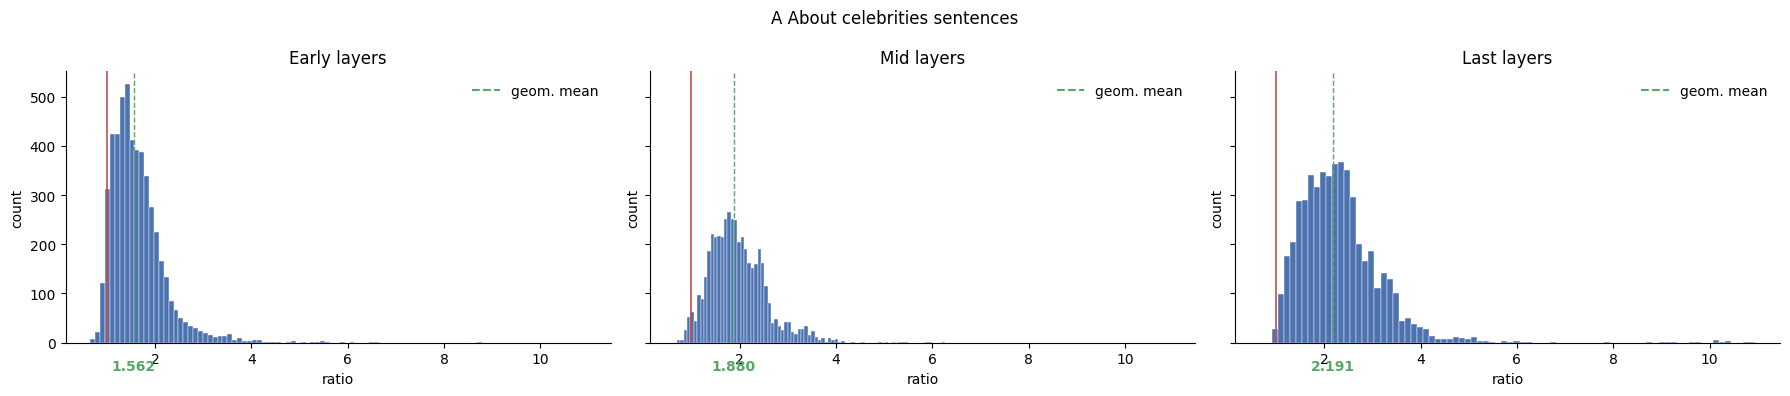

In [134]:
plot_by_groups(a_early_group,a_mid_group,a_last_group, "A About celebrities sentences")

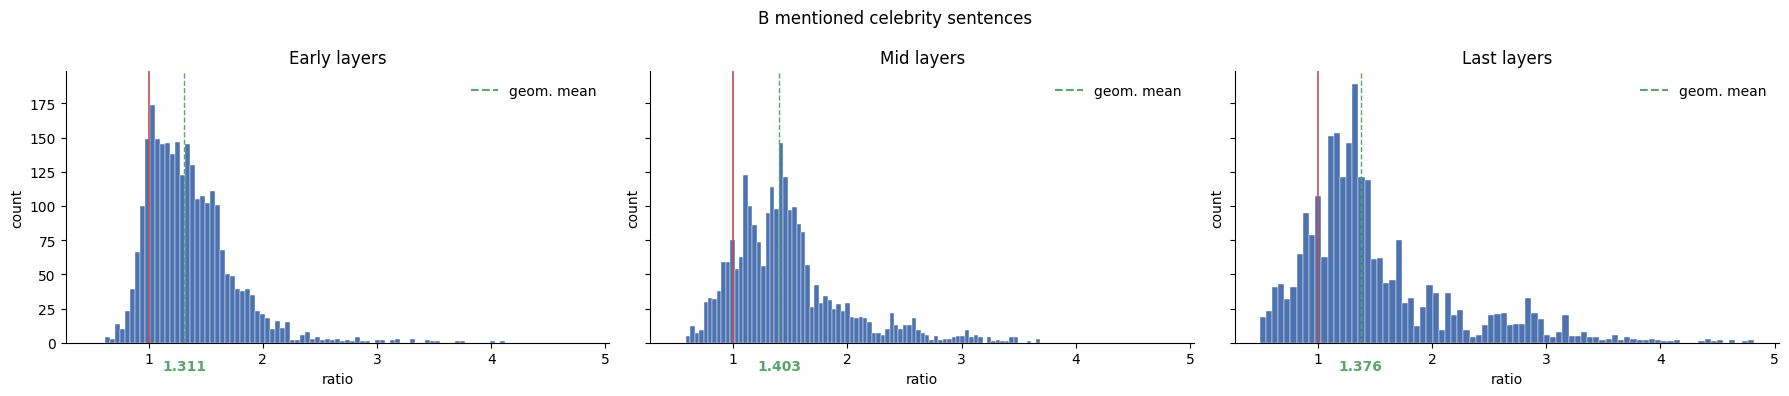

In [135]:
plot_by_groups(b_early_group,b_mid_group,b_last_group, "B mentioned celebrity sentences")

In [152]:
##VIBE CODED
import matplotlib.ticker as mticker

def plot_by_groups_log_scale(early_layers:torch.Tensor,mid_layers:torch.tensor,last_layers:torch.tensor,suptitle:str|None=None,bins:int=80,ratio_extent:float|None=None)->None:#input dime (sentncesx layers(in group)xpoisiton (after name))
    tensors = [early_layers, mid_layers, last_layers]
    titles = ["Early layers", "Mid layers", "Last layers"]

    # --- prep all data once ---
    xs = []
    for t in tensors:
        x = t.detach().float().cpu().numpy().ravel()
        x = x[np.isfinite(x)]
        assert (x > 0).all()
        xs.append(x)

    # reuse a previous plot's scale if given; otherwise derive from data
    if ratio_extent is None:
        gmin = min(x.min() for x in xs)
        gmax = max(x.max() for x in xs)
        ratio_extent = max(1.0 / gmin, gmax)   # farthest ratio from 1, either side

    # symmetric, log-spaced bins from 1/ratio_extent to ratio_extent (centered on 1)
    edges = np.logspace(np.log10(1.0 / ratio_extent), np.log10(ratio_extent), bins + 1)

    # tick positions: integers 1..9 per decade (up to ratio_extent) and their reciprocals
    pos = []
    for exp in range(0, int(np.ceil(np.log10(ratio_extent))) + 1):
        for d in range(1, 10):
            v = d * 10.0 ** exp
            if v <= ratio_extent * 1.0001:
                pos.append(v)
    ticks = sorted(set(pos + [1.0 / v for v in pos]))

    def ratio_fmt(v, _=None):
        if v >= 1:
            return f"{round(v):g}"
        r = 1.0 / v
        return f"1/{round(r):g}"

    fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharex=True, sharey=True)

    for ax, x, title in zip(axes, xs, titles):
        geo_mean = np.exp(np.log(x).mean())

        ax.hist(x, bins=edges, color="#4c72b0", edgecolor="white", linewidth=0.3)
        ax.set_xscale("log")
        ax.set_xlim(1.0 / ratio_extent, ratio_extent)   # symmetric around 1

        ax.xaxis.set_major_locator(mticker.FixedLocator(ticks))
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(ratio_fmt))
        ax.xaxis.set_minor_locator(mticker.NullLocator())
        ax.tick_params(axis="x", which="major", labelsize=7, rotation=90)

        ax.axvline(1.0, color="#c44e52", linewidth=1.2)
        ax.axvline(geo_mean, color="#55a868", linewidth=1.0, linestyle="--")

        ax.text(geo_mean, -0.06, f"{geo_mean:.3f}", ha="center", va="top",
                color="#55a868", fontweight="bold",
                transform=ax.get_xaxis_transform())

        ax.plot([], [], color="#55a868", linestyle="--", label="geom. mean")

        ax.set_title(title)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.set_xlabel("ratio")
        ax.set_ylabel("count")
        ax.legend(frameon=False)

    if suptitle is not None:
        fig.suptitle(suptitle)

    plt.tight_layout()
    plt.show()

    return ratio_extent


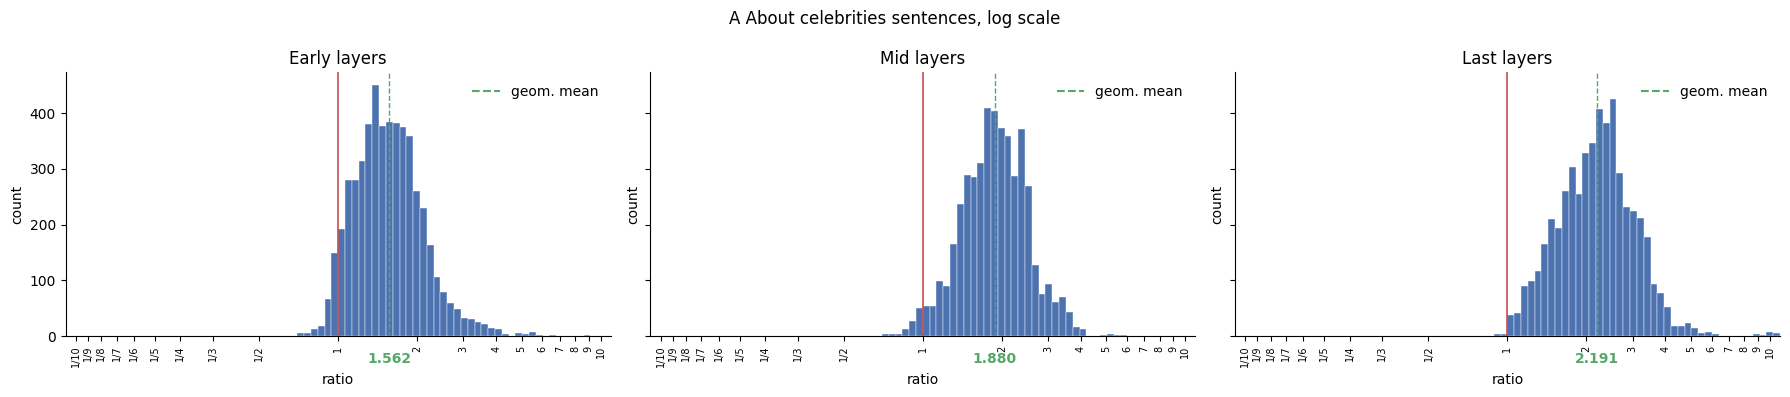

In [156]:
ratio_extent = plot_by_groups_log_scale(a_early_group,a_mid_group,a_last_group, "A About celebrities sentences, log scale")

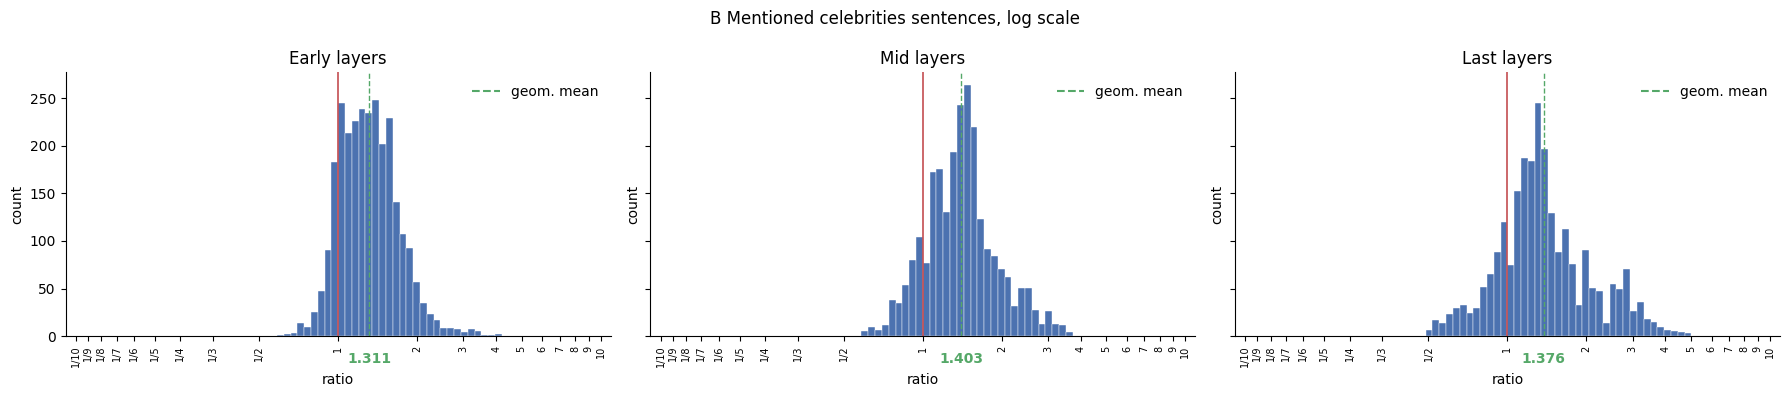

np.float32(10.947543)

In [158]:
plot_by_groups_log_scale(b_early_group,b_mid_group,b_last_group, "B Mentioned celebrities sentences, log scale",ratio_extent=ratio_extent)